# Beyond Stated Preferences: Building a Better Match Predictor for Dating Apps

**Dataset:** Columbia Business School Speed Dating Experiment (Fisman & Iyengar)  
**Scope:** 551 participants — 8,378 encounters — 21 experimental waves  
**Author:** Arvind B.  
**Last updated:** March 2026  

---

> *"People don't choose what they say they want.  
> This project quantifies that gap — and builds a better predictor from it."*

---

## Table of Contents

- [Section 0 — Introduction & Business Context](#section-0)
- [Section 1 — Business Framing](#section-1)
- [Section 2 — Exploratory Data Analysis](#section-2)
- [Section 3 — Feature Engineering](#section-3)
- [Section 4 — Modeling](#section-4)
- [Section 5 — Interpretability & Action Levers](#section-5)
- [Section 6 — Business Recommendations](#section-6)

## Section 0 — Introduction & Business Context <a id="section-0"></a>

### 0.1 Project Pitch

Match rates in speed dating events hover around **16.5%** — meaning 8 out of 10 encounters lead nowhere.

Most dating apps try to solve this by asking users what they want: rate the importance of attractiveness, intelligence, shared interests. Then they match people accordingly.

**The problem:** this data suggests people don't actually choose what they say they want.

This project uses the Columbia Speed Dating dataset to:
1. **Quantify the gap** between stated preferences and revealed choices
2. **Measure the self-overestimation bias** — and its impact on match rates
3. **Build a match prediction model** trained on what people *actually* respond to, not what they claim to

The output is a data-driven foundation for a smarter recommendation engine — one that replaces declared preferences with behavioral signals.

### 0.2 Dataset Architecture

The dataset was collected during experimental speed dating events organized by Columbia Business School between 2002 and 2004.

**Structure:** Each row represents **one encounter between two participants** — not one participant.  
If participant A meets participant B, there are two rows: A's perspective and B's perspective.

**Three temporal layers:**

| Layer | Timing | Variables |
|---|---|---|
| Pre-event | Before the night | Stated preferences, demographic info, self-ratings |
| During event | After each 4-minute date | Scores given to each partner (attractiveness, fun, sincerity, intelligence, ambition, shared interests) |
| Post-event | Day after & 3 weeks later | Updated preferences, follow-up dates, satisfaction |

**Key variables:**

| Variable | Description |
|---|---|
| `match` | Target — 1 if both participants said yes to each other |
| `dec` / `dec_o` | Individual decision (yes/no) from each side |
| `attr` / `attr_o` | Attractiveness score given / received |
| `attr1_1` | Stated importance of attractiveness before the event |
| `attr3_1` | Self-rated attractiveness before the event |
| `int_corr` | Correlation of interests between the two participants |
| `samerace` | 1 if both participants share the same racial background |

In [3]:
# ── 0.3 Setup — Imports & Data Loading ────────────────────────────────────

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

print("Libraries loaded successfully")

Libraries loaded successfully


### Project Structure
```
speed-dating-match-prediction/
│
├── data/                          # Raw dataset (not pushed to GitHub)
│   └── Speed_Dating_Data.csv
│
├── notebooks/                     # Main analysis notebook
│   └── speed_dating_analysis.ipynb
│
├── outputs/                       # Charts, tables, model outputs
│
├── src/                           # Helper functions (future)
│
├── presentations/                 # Business presentation (future)
│
└── README.md
```

In [4]:
# Robust path resolution regardless of VS Code working directory
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
DATA_PATH = os.path.join(BASE_DIR, "data", "Speed_Dating_Data.csv")

df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

print(f"Shape: {df.shape}")
print(f"Unique participants: {df['iid'].nunique()}")
print(f"Waves: {df['wave'].nunique()}")
print(f"Mean encounters per participant: {df.groupby('iid').size().mean():.1f}")

Shape: (8378, 195)
Unique participants: 551
Waves: 21
Mean encounters per participant: 15.2


## Section 1 — Business Framing <a id="section-1"></a>

### 1.1 Business Context

A dating app is experiencing a **decline in match rates**.

The product team's hypothesis: the current recommendation engine relies on **stated preferences** — what users say they want when setting up their profile. But if users don't actually choose what they claim to want, the entire matching logic is built on flawed inputs.

**The business stakes:**
- Low match rates → poor user experience → churn
- A 1% improvement in match rate across 1M daily users = 10,000 additional matches per day
- Better matches → longer sessions, higher retention, stronger monetization

**Our role:** acting as the data science team embedded with the product manager, we use the Columbia Speed Dating dataset as a proxy for real app behavior. The experimental design — controlled encounters, pre/during/post measurements — makes it uniquely suited to test the stated vs. revealed preference hypothesis.

### 1.2 The Two Types of Errors and Their Cost

In a binary match prediction model, two types of errors are possible:

| Error | Definition | Business Impact |
|---|---|---|
| **False Negative** | Model predicts no match — but both users would have said yes | Missed connection — user never sees a potentially good match → frustration, churn |
| **False Positive** | Model predicts match — but one or both users say no | Bad recommendation — erodes trust in the app over time |

**Which error is more costly?**

In a dating app context, **false negatives are more damaging** than false positives.  
A user who never gets a good match leaves. A user who gets an occasional bad recommendation stays — and keeps swiping.

**Implication for modeling:**  
We will optimize for **recall** on the positive class (match = 1), accepting a moderate precision trade-off.  
Our primary evaluation metric will be **AUC-ROC**, complemented by **F1-score**.  
Accuracy alone is misleading here — a model that always predicts "no match" achieves 83.5% accuracy while being completely useless.

### 1.3 Stakeholders

| Stakeholder | Role | What they need from this analysis |
|---|---|---|
| **Product Manager** | Owns the recommendation engine roadmap | Clear evidence that stated preferences are poor signals — justification to redesign the matching algorithm |
| **Data Science Team** | Builds and maintains the model | Reliable features, interpretable model, reproducible pipeline |
| **Growth & Retention Team** | Tracks match rates, session length, churn | Quantified impact of improving match prediction on key business metrics |
| **UX Team** | Designs the onboarding flow | Insights on self-overestimation bias — to redesign how users set up their profiles |
| **Users** | End consumers | More relevant matches, less time wasted |

**Primary audience for this analysis:** the Product Manager and the Data Science Team.  
Recommendations in Section 6 are framed accordingly — actionable, specific, tied to product decisions.

### 1.4 The Three Business Questions

This analysis is structured around three questions, each building on the previous one:

| # | Question | Method | Output |
|---|---|---|---|
| **Q1** | Do stated preferences predict actual choices? | Correlation analysis, statistical testing | Quantified gap between declared weights and revealed drivers |
| **Q2** | Do users who overestimate themselves match less? | Self-rating vs. received rating comparison, segmentation by gender | Overestimation score and its impact on individual match rate |
| **Q3** | Can we predict a mutual match from behavioral signals? | Classification model (Logistic Regression + XGBoost) | AUC-ROC, F1, actionable feature importance |

**The logical thread:**  
Q1 demonstrates that the current matching logic is flawed.  
Q2 identifies a specific behavioral bias that compounds the problem.  
Q3 builds a better predictor — trained on what people *actually* respond to.

## Section 2 — Exploratory Data Analysis <a id="section-2"></a>

### 2.1 Dataset Audit

Before any analysis, we systematically audit the dataset:
- Shape and data types
- Missing values
- Target variable distribution

In [5]:
# ── 2.1 Dataset Audit ────────────────────────────────────────────────────────

# Shape and dtypes
print("=== Shape ===")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

print("\n=== Data Types ===")
print(df.dtypes.value_counts())

print("\n=== Missing Values (top 20 columns) ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).query("missing_count > 0").sort_values("missing_pct", ascending=False)

print(missing_df.head(20).to_string())
print(f"\nTotal columns with missing values: {len(missing_df)}")

=== Shape ===
Rows: 8,378 | Columns: 195

=== Data Types ===
float64    174
int64       13
object       8
Name: count, dtype: int64

=== Missing Values (top 20 columns) ===
          missing_count  missing_pct
num_in_3           7710       92.000
numdat_3           6882       82.100
expnum             6578       78.500
sinc7_2            6423       76.700
amb7_2             6423       76.700
shar7_2            6404       76.400
attr7_2            6394       76.300
intel7_2           6394       76.300
fun7_2             6394       76.300
amb5_3             6362       75.900
sinc7_3            6362       75.900
intel7_3           6362       75.900
fun7_3             6362       75.900
amb7_3             6362       75.900
shar7_3            6362       75.900
attr7_3            6362       75.900
fun5_3             6362       75.900
intel5_3           6362       75.900
sinc5_3            6362       75.900
attr5_3            6362       75.900

Total columns with missing values: 182


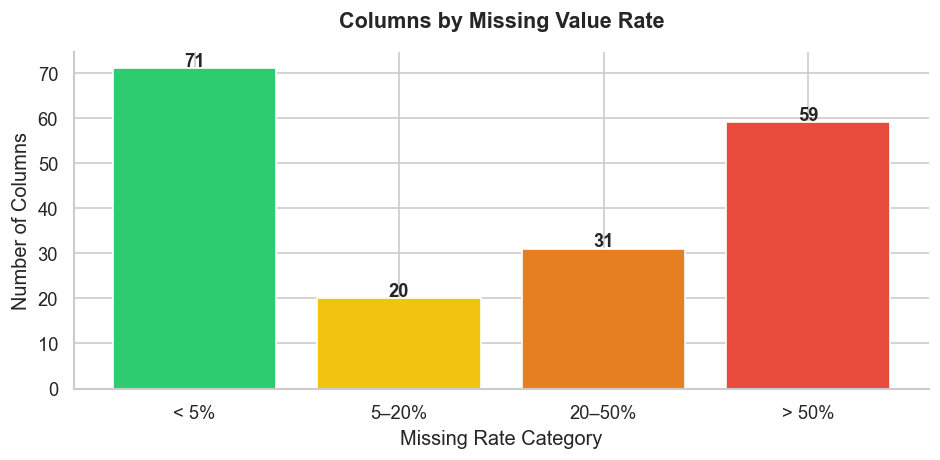


Interpretation:
Columns with >50% missing will be excluded from modeling.
Columns with <5% missing will be imputed with median.


In [6]:
# ── Missing values visualization ─────────────────────────────────────────────

# Group columns by missing rate
missing_df["category"] = pd.cut(
    missing_df["missing_pct"],
    bins=[0, 5, 20, 50, 100],
    labels=["< 5%", "5–20%", "20–50%", "> 50%"]
)

category_counts = missing_df["category"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(category_counts.index, category_counts.values, color=["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"])
ax.set_title("Columns by Missing Value Rate", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Missing Rate Category")
ax.set_ylabel("Number of Columns")

for bar, val in zip(bars, category_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/missing_values_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("Columns with >50% missing will be excluded from modeling.")
print("Columns with <5% missing will be imputed with median.")

### Missing Values Strategy

| Missing Rate | Count | Decision |
|---|---|---|
| < 5% | 71 columns | Keep — impute with median |
| 5–20% | 20 columns | Keep — impute with median, flag if modeling feature |
| 20–50% | 31 columns | Case by case — keep only if analytically relevant |
| > 50% | 59 columns | Exclude from modeling |

**Key observation:** The columns with >50% missing are almost exclusively post-event follow-up variables (Time 2 and Time 3 surveys). This is expected — many participants did not complete the follow-up surveys.

**For the analysis:** during-event scores (`attr`, `fun`, `sinc`, `intel`, `amb`, `shar`) have less than 13% missing and will form the core feature set for modeling.

### 2.2 Target Variable Analysis

The target variable is `match` — 1 if both participants said yes to each other, 0 otherwise.

Two related variables help understand the asymmetry:
- `dec` — the participant's own decision (yes/no)
- `dec_o` — the partner's decision (yes/no)

A match only occurs when **both** say yes. This creates a compounding effect:
even if individual acceptance rates are moderate, mutual match rates are much lower.

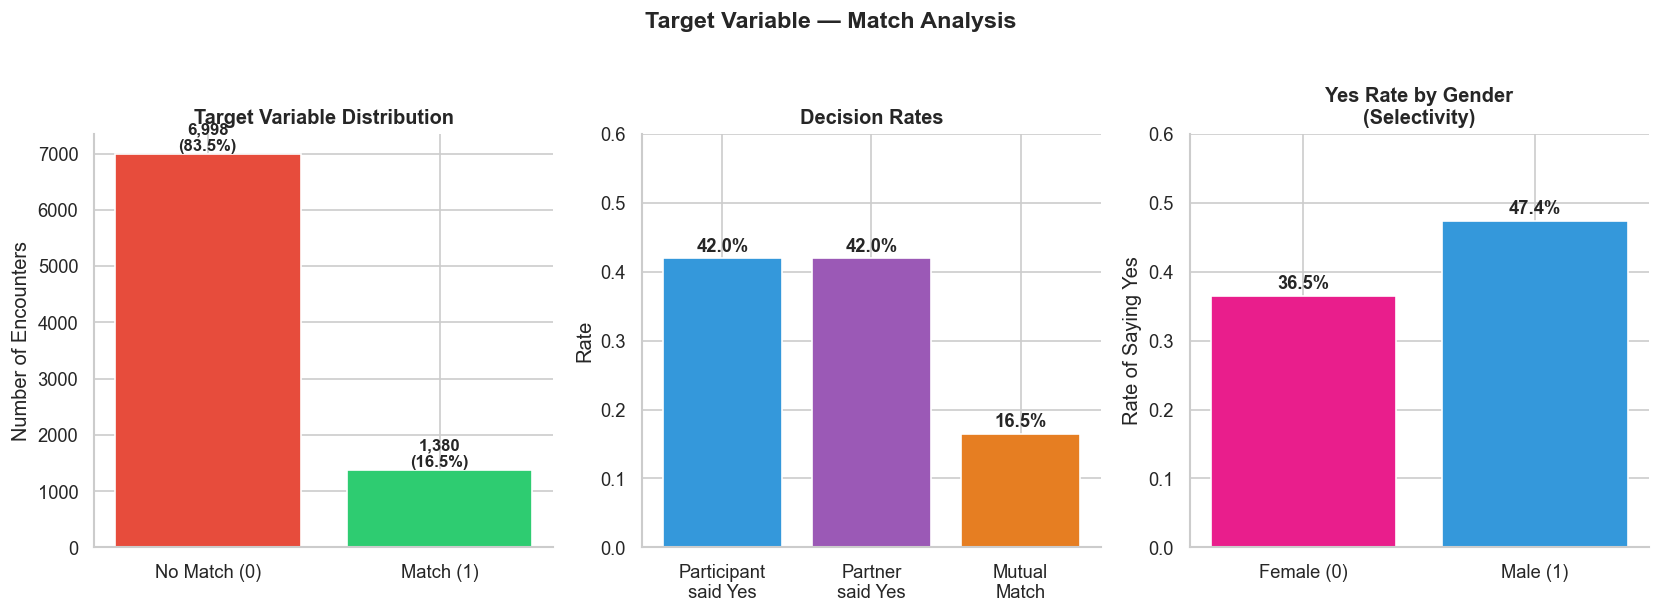


Key insight: Individual acceptance rate (~42%) vs mutual match rate (16.5%)
The gap confirms that reciprocity is the core challenge, not individual willingness.

Selectivity by gender:
Female yes rate: 36.5%
Male yes rate:   47.4%


In [8]:
# ── 2.2 Target Variable Analysis ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# --- Plot 1: Match distribution ---
match_counts = df['match'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['No Match (0)', 'Match (1)'], match_counts.values, color=colors)
axes[0].set_title('Target Variable Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Encounters')
for i, v in enumerate(match_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# --- Plot 2: Individual decision rates ---
dec_rates = {
    'Participant\nsaid Yes': df['dec'].mean(),
    'Partner\nsaid Yes': df['dec_o'].mean(),
    'Mutual\nMatch': df['match'].mean()
}
bars = axes[1].bar(dec_rates.keys(), dec_rates.values(),
                   color=['#3498db', '#9b59b6', '#e67e22'])
axes[1].set_title('Decision Rates', fontweight='bold')
axes[1].set_ylabel('Rate')
axes[1].set_ylim(0, 0.6)
for bar, val in zip(bars, dec_rates.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

# --- Plot 3: Decision rate by gender (selectivity) ---
gender_dec = df.groupby('gender')['dec'].mean()
bars3 = axes[2].bar(['Female (0)', 'Male (1)'], gender_dec.values,
                    color=['#e91e8c', '#3498db'])
axes[2].set_title('Yes Rate by Gender\n(Selectivity)', fontweight='bold')
axes[2].set_ylabel('Rate of Saying Yes')
axes[2].set_ylim(0, 0.6)
for i, val in enumerate(gender_dec.values):
    axes[2].text(i, val + 0.01, f'{val:.1%}',
                 ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Target Variable — Match Analysis', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/target_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nKey insight: Individual acceptance rate (~42%) vs mutual match rate (16.5%)")
print(f"The gap confirms that reciprocity is the core challenge, not individual willingness.")
print(f"\nSelectivity by gender:")
print(f"Female yes rate: {gender_dec[0]:.1%}")
print(f"Male yes rate:   {gender_dec[1]:.1%}")

### Key Observations — Target Variable

**1. Severe class imbalance**
83.5% of encounters result in no match. A naive model predicting "no match" every time
would achieve 83.5% accuracy — which is why accuracy is not our evaluation metric.

**2. The reciprocity gap**
Individual yes rate: ~42% on both sides.
Mutual match rate: 16.5%.
The math of reciprocity alone explains most of the gap: 0.42 × 0.42 ≈ 17.6%, 
close to the observed 16.5%. This suggests decisions are close to independent —
people are not strategically adjusting their choices based on perceived reciprocity.

**3. Gender selectivity**
Women say yes 36.5% of the time vs. 47.4% for men — an 11-point gap.
Women are more selective. This is consistent with the original Fisman & Iyengar findings.
Implication for the app: recommendation quality matters more for female users,
as they apply a higher bar before saying yes.

### 2.3 Stated vs. Revealed Preferences

**The central question:** Do people choose what they say they want?

Before the event, participants distributed 100 points across 6 attributes to express
what they look for in a potential date (`attr1_1`, `sinc1_1`, `intel1_1`, `fun1_1`, 
`amb1_1`, `shar1_1`).

During the event, they rated each partner on the same 6 attributes (`attr`, `sinc`, 
`intel`, `fun`, `amb`, `shar`).

We compare:
- **Stated importance** — the weight assigned to each attribute before the event
- **Revealed importance** — the correlation between each attribute score and the match outcome

/var/folders/39/9v2r64292m98c6c1_qf1hf_r0000gn/T/ipykernel_14889/1902696889.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(attrs, rotation=25, ha='right')


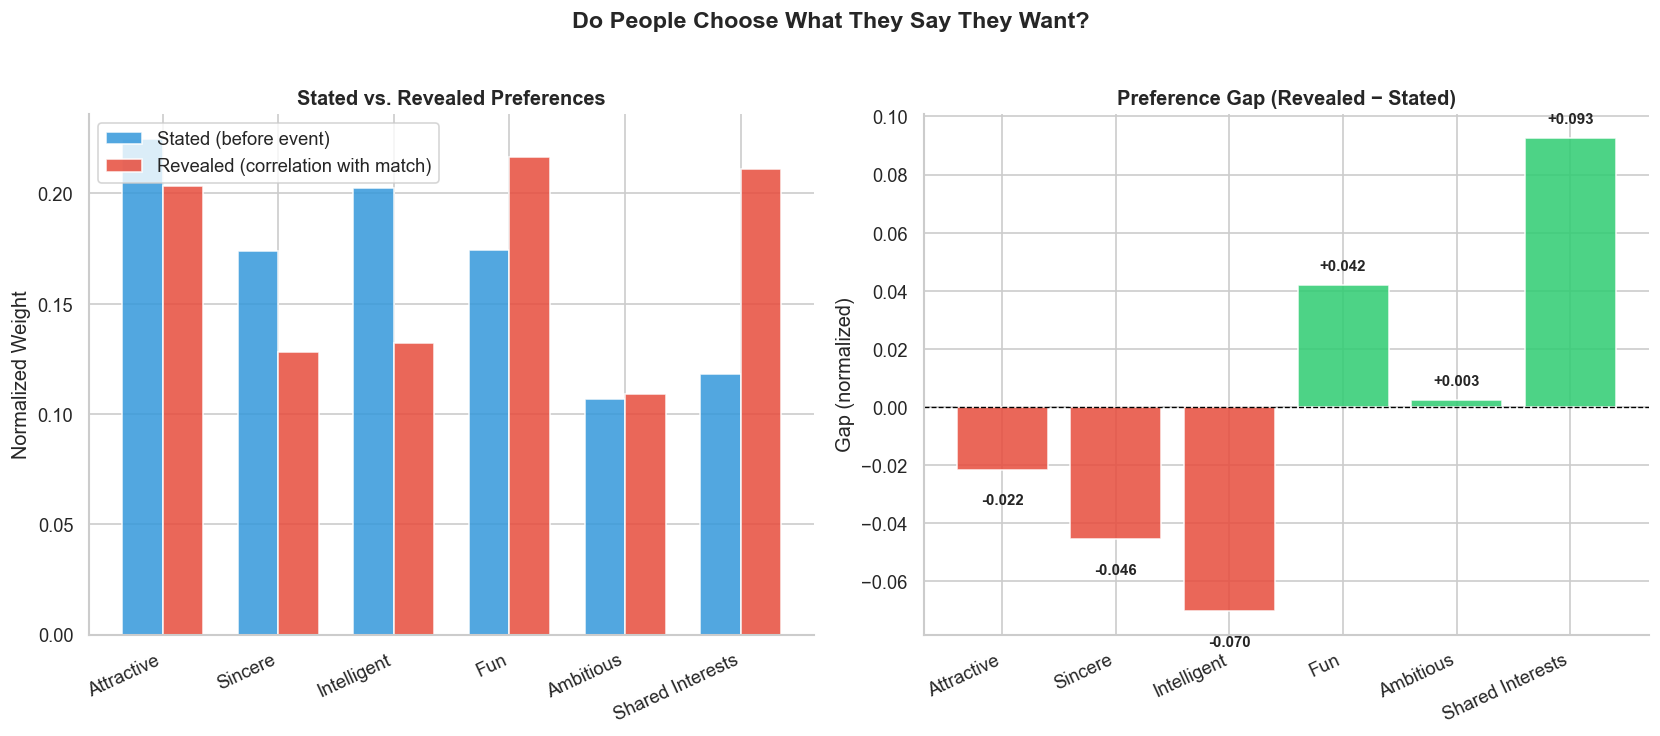

Stated preferences (normalized):
Attractive         0.225
Sincere            0.174
Intelligent        0.202
Fun                0.174
Ambitious          0.107
Shared Interests   0.118
dtype: float64

Revealed importance (normalized):
Attractive         0.203
Sincere            0.128
Intelligent        0.132
Fun                0.216
Ambitious          0.109
Shared Interests   0.211
dtype: float64


In [9]:
# ── 2.3 Stated vs. Revealed Preferences ──────────────────────────────────────

# Stated preferences — mean weight assigned before event
stated = df[['attr1_1','sinc1_1','intel1_1','fun1_1','amb1_1','shar1_1']].mean()
stated.index = ['Attractive', 'Sincere', 'Intelligent', 'Fun', 'Ambitious', 'Shared Interests']

# Revealed importance — correlation with match outcome
revealed = df[['attr','sinc','intel','fun','amb','shar']].corrwith(df['match'])
revealed.index = ['Attractive', 'Sincere', 'Intelligent', 'Fun', 'Ambitious', 'Shared Interests']

# Normalize stated to 0-1 for visual comparison
stated_norm = stated / stated.sum()
revealed_norm = revealed / revealed.sum()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
attrs = stated_norm.index
x = np.arange(len(attrs))
width = 0.35

# --- Plot 1: Side by side comparison ---
bars1 = axes[0].bar(x - width/2, stated_norm.values, width,
                    label='Stated (before event)', color='#3498db', alpha=0.85)
bars2 = axes[0].bar(x + width/2, revealed_norm.values, width,
                    label='Revealed (correlation with match)', color='#e74c3c', alpha=0.85)
axes[0].set_title('Stated vs. Revealed Preferences', fontweight='bold')
axes[0].set_ylabel('Normalized Weight')
axes[0].set_xticks(x)
axes[0].set_xticklabels(attrs, rotation=25, ha='right')
axes[0].legend()

# --- Plot 2: Gap (revealed - stated) ---
gap = revealed_norm.values - stated_norm.values
colors_gap = ['#2ecc71' if g > 0 else '#e74c3c' for g in gap]
axes[1].bar(attrs, gap, color=colors_gap, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Preference Gap (Revealed − Stated)', fontweight='bold')
axes[1].set_ylabel('Gap (normalized)')
axes[1].set_xticklabels(attrs, rotation=25, ha='right')
axes[1].set_xticks(range(len(attrs)))
for i, (val, attr) in enumerate(zip(gap, attrs)):
    axes[1].text(i, val + (0.005 if val > 0 else -0.012),
                 f'{val:+.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Do People Choose What They Say They Want?', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/stated_vs_revealed.png', dpi=120, bbox_inches='tight')
plt.show()

print("Stated preferences (normalized):")
print(stated_norm.round(3))
print("\nRevealed importance (normalized):")
print(revealed_norm.round(3))

### Key Findings — Stated vs. Revealed Preferences

| Attribute | Stated Weight | Revealed Weight | Gap | Direction |
|---|---|---|---|---|
| Attractive | 22.5% | 20.3% | -0.022 | Slight overestimate |
| Sincere | 17.4% | 12.8% | -0.046 | **Overestimated** |
| Intelligent | 20.2% | 13.2% | -0.070 | **Strongly overestimated** |
| Fun | 17.4% | 21.6% | +0.042 | **Underestimated** |
| Ambitious | 10.7% | 10.9% | +0.003 | Accurate |
| Shared Interests | 11.8% | 21.1% | +0.093 | **Strongly underestimated** |

**Interpretation:**
- Intelligence and sincerity are "virtue signaling" attributes — people declare them important
  because it sounds good, but they don't drive actual match decisions.
- Fun and shared interests are the real drivers — underweighted in stated preferences
  but strongly predictive of mutual match.
- Attractiveness is the only attribute accurately self-assessed in terms of importance.

**Business implication:** A recommendation engine built on stated preferences
systematically misallocates weight. It over-indexes on intelligence and sincerity,
and under-indexes on the two attributes that actually predict matches.

In [10]:
# ── Statistical validation of the preference gap ─────────────────────────────

from scipy.stats import pearsonr, spearmanr

attributes = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
stated_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
labels = ['Attractive', 'Sincere', 'Intelligent', 'Fun', 'Ambitious', 'Shared Interests']

print("=== Correlation with match outcome (Pearson) ===\n")
print(f"{'Attribute':<20} {'Correlation':>12} {'p-value':>12} {'Significant':>12}")
print("-" * 58)

for attr, label in zip(attributes, labels):
    clean = df[[attr, 'match']].dropna()
    corr, pval = pearsonr(clean[attr], clean['match'])
    sig = "YES ***" if pval < 0.001 else ("YES *" if pval < 0.05 else "NO")
    print(f"{label:<20} {corr:>12.4f} {pval:>12.2e} {sig:>12}")

print("\n=== Stated preference weights (mean across participants) ===\n")
print(f"{'Attribute':<20} {'Stated Weight':>14} {'Std Dev':>10}")
print("-" * 46)
for col, label in zip(stated_cols, labels):
    mean = df[col].mean()
    std = df[col].std()
    print(f"{label:<20} {mean:>14.2f} {std:>10.2f}")

print("\n=== Spearman rank correlation — stated vs revealed ranking ===")
stated_ranks = pd.Series(stated_norm.values, index=labels).rank(ascending=False)
revealed_ranks = pd.Series(revealed_norm.values, index=labels).rank(ascending=False)
rho, pval = spearmanr(stated_ranks.values, revealed_ranks.values)
print(f"\nSpearman rho: {rho:.3f} | p-value: {pval:.3f}")
print("Interpretation: rho close to 1 = rankings match, close to 0 = no alignment")

=== Correlation with match outcome (Pearson) ===

Attribute             Correlation      p-value  Significant
----------------------------------------------------------
Attractive                 0.2607    4.20e-127      YES ***
Sincere                    0.1644     3.27e-50      YES ***
Intelligent                0.1695     3.55e-53      YES ***
Fun                        0.2775    6.32e-142      YES ***
Ambitious                  0.1400     7.05e-35      YES ***
Shared Interests           0.2707    5.92e-123      YES ***

=== Stated preference weights (mean across participants) ===

Attribute             Stated Weight    Std Dev
----------------------------------------------
Attractive                    22.51      12.59
Sincere                       17.40       7.05
Intelligent                   20.27       6.78
Fun                           17.46       6.09
Ambitious                     10.68       6.12
Shared Interests              11.85       6.36

=== Spearman rank correlation —

### Statistical Validation

All 6 attributes are significantly correlated with match outcome (p < 0.001),
confirming that each attribute carries real predictive signal.

The critical test is the **Spearman rank correlation** between stated and revealed rankings:

> **ρ = 0.371, p = 0.468**

A rho of 0.37 indicates weak alignment between what people say they want
and what actually predicts their choices.
The non-significant p-value (0.468) means we cannot reject the null hypothesis
that stated rankings are unrelated to revealed rankings.

**Conclusion:** The rank order of stated preferences is statistically indistinguishable
from random with respect to actual match behavior.
This directly invalidates the assumption behind preference-based recommendation engines.

### 2.4 Self-Overestimation Bias

**The question:** Do participants accurately assess their own attractiveness?
And does overestimating oneself hurt match rates?

Three self-perception variables are available:
- `attr3_1` — how attractive the participant thinks they are (before event)
- `attr5_1` — how the participant thinks *others* perceive them (before event)
- `attr` — how partners actually rated them during the event

We compute an **overestimation score** per participant:
> `overestimation = attr3_1 − mean(attr received from all partners)`

A positive score means the participant thinks more highly of themselves
than their partners do. A negative score means they underestimate themselves.

In [11]:
# ── 2.4 Self-Overestimation Bias ─────────────────────────────────────────────

# Mean attractiveness score received per participant
attr_received = df.groupby('iid')['attr'].mean().rename('attr_received')

# Self-rating before event (one value per participant)
attr_self = df.groupby('iid')['attr3_1'].first().rename('attr_self')

# How they think others perceive them
attr_perceived = df.groupby('iid')['attr5_1'].first().rename('attr_perceived')

# Gender per participant
gender = df.groupby('iid')['gender'].first()

# Match rate per participant
match_rate = df.groupby('iid')['match'].mean().rename('match_rate')

# Combine
participant_df = pd.concat([attr_self, attr_perceived, attr_received,
                            gender, match_rate], axis=1).dropna()

# Overestimation score
participant_df['overestimation'] = participant_df['attr_self'] - participant_df['attr_received']

print(f"Participants in analysis: {len(participant_df)}")
print(f"\nMean self-rating:       {participant_df['attr_self'].mean():.2f}")
print(f"Mean perceived by others: {participant_df['attr_perceived'].mean():.2f}")
print(f"Mean rating received:   {participant_df['attr_received'].mean():.2f}")
print(f"\nMean overestimation score: {participant_df['overestimation'].mean():.2f}")
print(f"% who overestimate:        {(participant_df['overestimation'] > 0).mean():.1%}")
print(f"% who underestimate:       {(participant_df['overestimation'] < 0).mean():.1%}")

Participants in analysis: 314

Mean self-rating:       7.06
Mean perceived by others: 6.93
Mean rating received:   6.16

Mean overestimation score: 0.90
% who overestimate:        71.0%
% who underestimate:       27.1%


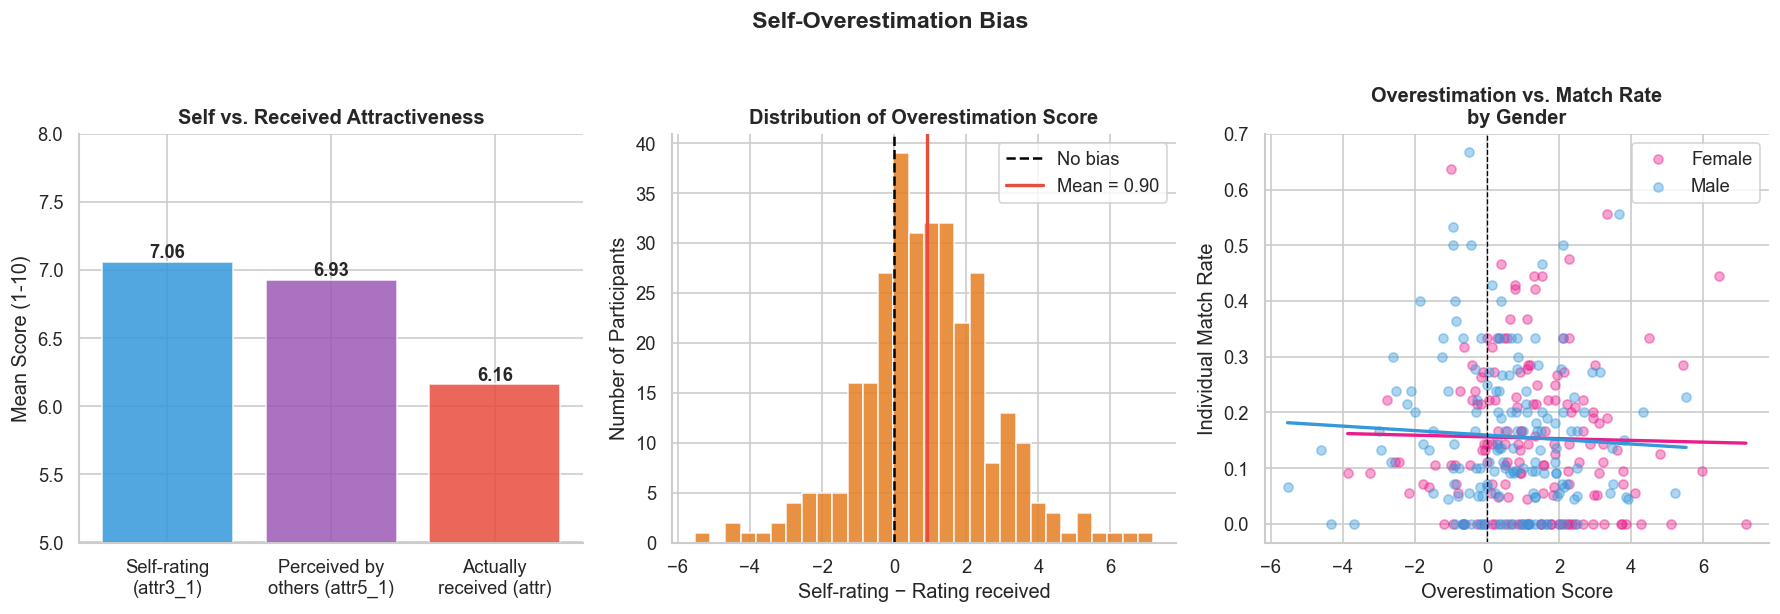

Correlation overestimation vs match rate — Female: -0.021 | Male: -0.052


In [12]:
# ── Overestimation bias visualization ────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: Self vs received rating ---
means = [participant_df['attr_self'].mean(),
         participant_df['attr_perceived'].mean(),
         participant_df['attr_received'].mean()]
labels = ['Self-rating\n(attr3_1)', 'Perceived by\nothers (attr5_1)', 'Actually\nreceived (attr)']
colors = ['#3498db', '#9b59b6', '#e74c3c']

bars = axes[0].bar(labels, means, color=colors, alpha=0.85)
axes[0].set_title('Self vs. Received Attractiveness', fontweight='bold')
axes[0].set_ylabel('Mean Score (1-10)')
axes[0].set_ylim(5, 8)
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# --- Plot 2: Distribution of overestimation score ---
axes[1].hist(participant_df['overestimation'], bins=30,
             color='#e67e22', alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--', label='No bias')
axes[1].axvline(participant_df['overestimation'].mean(), color='#e74c3c',
                linewidth=2, linestyle='-', label=f"Mean = {participant_df['overestimation'].mean():.2f}")
axes[1].set_title('Distribution of Overestimation Score', fontweight='bold')
axes[1].set_xlabel('Self-rating − Rating received')
axes[1].set_ylabel('Number of Participants')
axes[1].legend()

# --- Plot 3: Overestimation vs match rate by gender ---
for gender_val, color, label in zip([0, 1], ['#e91e8c', '#3498db'], ['Female', 'Male']):
    subset = participant_df[participant_df['gender'] == gender_val]
    axes[2].scatter(subset['overestimation'], subset['match_rate'],
                    alpha=0.4, color=color, label=label, s=30)
    # Trend line
    z = np.polyfit(subset['overestimation'], subset['match_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['overestimation'].min(), subset['overestimation'].max(), 100)
    axes[2].plot(x_line, p(x_line), color=color, linewidth=2)

axes[2].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Overestimation vs. Match Rate\nby Gender', fontweight='bold')
axes[2].set_xlabel('Overestimation Score')
axes[2].set_ylabel('Individual Match Rate')
axes[2].legend()

plt.suptitle('Self-Overestimation Bias', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/overestimation_bias.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlation overestimation vs match rate
corr_f = participant_df[participant_df['gender']==0]['overestimation'].corr(
         participant_df[participant_df['gender']==0]['match_rate'])
corr_m = participant_df[participant_df['gender']==1]['overestimation'].corr(
         participant_df[participant_df['gender']==1]['match_rate'])
print(f"Correlation overestimation vs match rate — Female: {corr_f:.3f} | Male: {corr_m:.3f}")

### Key Findings — Self-Overestimation Bias

**71% of participants overestimate their own attractiveness.**
Mean self-rating: 7.06 / Mean rating actually received: 6.16 — a gap of **0.90 points**.

Participants also believe others perceive them almost as highly as they perceive themselves
(attr5_1 = 6.93), meaning the bias extends to their perception of how others see them.

**Does overestimation hurt match rates?**

| Gender | Correlation (overestimation vs match rate) | Direction |
|---|---|---|
| Female | -0.021 | Negative but weak |
| Male | -0.052 | Negative but weak |

The relationship is in the expected direction — higher overestimation correlates
with lower match rates — but the effect is small.

**Interpretation:** Self-overestimation is widespread but not the dominant driver
of individual match rates. Actual scores received from partners (attractiveness, fun,
shared interests) carry much more predictive weight.

**Business implication for onboarding:** Even if overestimation doesn't directly
tank match rates, it creates misaligned expectations. Users who expect more matches
than they receive are more likely to churn. Calibrating self-perception during
onboarding (e.g. showing how users compare to the pool) could reduce early churn.

### 2.5 Temporal Dimension — How Preferences Shift

One of the unique features of this dataset is that preferences are measured
at three points in time:

| Time | Variable suffix | Context |
|---|---|---|
| **T1** — Before event | `_1` (e.g. `attr1_1`) | Stated at signup — what you think you want |
| **T2** — Day after | `_2` (e.g. `attr1_2`) | Restated after experience — what you think you wanted |
| **T3** — 3 weeks after | `_3` (e.g. `attr1_3`) | Restated after reflection and follow-up dates |

Additionally, `attr7_2` and `attr7_3` ask participants to retrospectively distribute
100 points reflecting how they **actually decided** during the event.

This allows two distinct comparisons:
- **Preference drift:** did stated preferences change after the experience?
- **Retrospective accuracy:** do people correctly identify what drove their decisions?

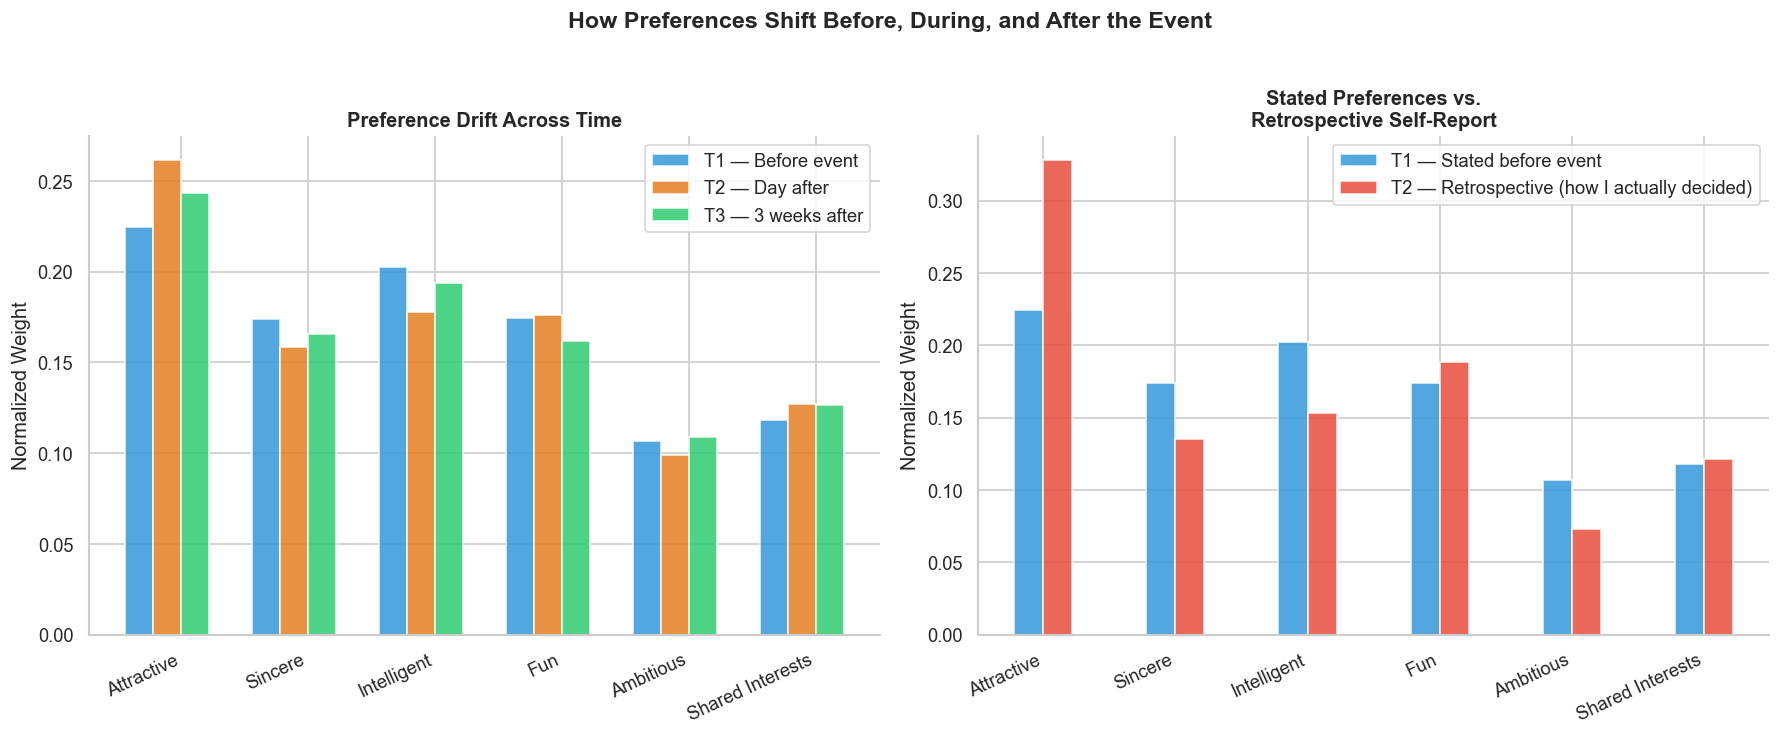

T1 (before): [0.225 0.174 0.202 0.174 0.107 0.118]
T2 (day after): [0.262 0.158 0.178 0.176 0.099 0.127]
T3 (3 weeks): [0.243 0.166 0.194 0.162 0.109 0.127]
T2 retro: [0.328 0.135 0.153 0.189 0.073 0.122]


In [13]:
# ── 2.5 Temporal Dimension ───────────────────────────────────────────────────

attrs = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
labels = ['Attractive', 'Sincere', 'Intelligent', 'Fun', 'Ambitious', 'Shared Interests']

# T1: stated before event
t1_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
# T2: stated day after
t2_cols = ['attr1_2', 'sinc1_2', 'intel1_2', 'fun1_2', 'amb1_2', 'shar1_2']
# T3: stated 3 weeks after
t3_cols = ['attr1_3', 'sinc1_3', 'intel1_3', 'fun1_3', 'amb1_3', 'shar1_3']
# T2 retrospective: how they think they actually decided
t2_retro_cols = ['attr7_2', 'sinc7_2', 'intel7_2', 'fun7_2', 'amb7_2', 'shar7_2']

# Compute means and normalize
def get_normalized(cols):
    means = df[cols].mean()
    return means / means.sum()

t1 = get_normalized(t1_cols)
t2 = get_normalized(t2_cols)
t3 = get_normalized(t3_cols)
t2_retro = get_normalized(t2_retro_cols)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(labels))
width = 0.22

# --- Plot 1: Preference drift across time ---
axes[0].bar(x - width*1.5, t1.values, width, label='T1 — Before event', color='#3498db', alpha=0.85)
axes[0].bar(x - width*0.5, t2.values, width, label='T2 — Day after', color='#e67e22', alpha=0.85)
axes[0].bar(x + width*0.5, t3.values, width, label='T3 — 3 weeks after', color='#2ecc71', alpha=0.85)
axes[0].set_title('Preference Drift Across Time', fontweight='bold')
axes[0].set_ylabel('Normalized Weight')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=25, ha='right')
axes[0].legend()

# --- Plot 2: Stated T1 vs retrospective T2 ---
axes[1].bar(x - width/2, t1.values, width,
            label='T1 — Stated before event', color='#3498db', alpha=0.85)
axes[1].bar(x + width/2, t2_retro.values, width,
            label='T2 — Retrospective (how I actually decided)', color='#e74c3c', alpha=0.85)
axes[1].set_title('Stated Preferences vs.\nRetrospective Self-Report', fontweight='bold')
axes[1].set_ylabel('Normalized Weight')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=25, ha='right')
axes[1].legend()

plt.suptitle('How Preferences Shift Before, During, and After the Event',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/temporal_preference_shift.png', dpi=120, bbox_inches='tight')
plt.show()

print("T1 (before):", t1.round(3).values)
print("T2 (day after):", t2.round(3).values)
print("T3 (3 weeks):", t3.round(3).values)
print("T2 retro:", t2_retro.round(3).values)

### Key Findings — Temporal Dimension

**Preference drift (T1 → T2 → T3) is minimal.**
Stated preferences remain largely stable across time.
The speed dating experience does not significantly reshape what people
think they are looking for in a partner.

**The retrospective self-report tells a different story.**

When asked the day after to reflect on how they *actually* decided,
participants dramatically shift their reported weights:

| Attribute | Stated T1 | Retrospective T2 | Shift |
|---|---|---|---|
| Attractive | 22.5% | 32.8% | **+10.3 pts** |
| Sincere | 17.4% | 13.5% | -3.9 pts |
| Intelligent | 20.2% | 15.3% | -4.9 pts |
| Fun | 17.4% | 18.9% | +1.5 pts |
| Ambitious | 10.7% | 7.3% | -3.4 pts |
| Shared Interests | 11.8% | 12.2% | +0.4 pts |

**Interpretation:** People don't update their preferences after the event —
but they do acknowledge, in hindsight, that attractiveness drove their decisions
more than they were willing to admit beforehand.

This is a form of **temporal social desirability bias**: before the event,
people signal virtue (intelligence, sincerity). After the event, faced with
their own choices, they partially admit the truth.

**Business implication:** Onboarding preference surveys are doubly flawed.
Not only do stated preferences not predict choices — users themselves
acknowledge this discrepancy the very next day.

### 2.6 EDA Synthesis

Three findings from this exploratory analysis directly motivate the modeling choices ahead.

**Finding 1 — The reciprocity problem**
Individual yes rates (~42%) are moderate, but mutual match rates collapse to 16.5%.
The core challenge is not convincing people to say yes — it is predicting *mutual* yes.
This makes match prediction a harder and more interesting problem than simple preference matching.

**Finding 2 — Stated preferences are unreliable inputs**
The Spearman rank correlation between stated and revealed preference rankings is 0.37 (p = 0.47).
Statistically indistinguishable from random. Intelligence and sincerity are systematically
overweighted in stated preferences; fun and shared interests are underweighted.
This invalidates the foundational assumption of preference-based recommendation engines.

**Finding 3 — Attractiveness is the dominant retrospective driver**
When participants reflect on their actual decisions, attractiveness jumps from 22.5%
to 32.8% of stated weight. The bias is not just between stated and revealed —
it exists within the participant's own self-report across time.

**Modeling implications**

| Decision | Rationale |
|---|---|
| Use during-event scores as primary features | They capture revealed behavior, not stated intent |
| Exclude stated preference variables from core model | Shown to be weak and biased signals |
| Include overestimation score as derived feature | Captures self-perception gap |
| Use AUC-ROC and F1 as evaluation metrics | Class imbalance makes accuracy misleading |
| Apply class weighting | 83.5% negative class requires explicit handling |

## Section 3 — Feature Engineering <a id="section-3"></a>

### 3.1 Data Cleaning & Imputation

The EDA identified three categories of columns:
- **> 50% missing:** excluded from modeling (mostly post-event follow-up variables)
- **5–50% missing:** imputed with median, flagged if used as modeling feature
- **< 5% missing:** imputed with median

Imputation strategy: **median** for all numeric features.
Rationale: rating scales (1-10) are bounded and often skewed — median is more robust
than mean and avoids introducing out-of-range values.

No categorical encoding is required for the core feature set,
as all primary features are numeric scores.

In [14]:
# ── 3.1 Data Cleaning & Imputation ───────────────────────────────────────────

# Core features for modeling — during-event scores only
core_features = [
    'attr', 'sinc', 'intel', 'fun', 'amb', 'shar',       # scores given to partner
    'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o',  # scores received from partner
    'like', 'prob',                                         # overall like + perceived probability
    'like_o', 'prob_o',                                     # partner's like + prob
    'int_corr', 'samerace',                                 # interest correlation, same race
    'age', 'age_o',                                         # age
    'attr3_1', 'attr5_1',                                   # self-rating, perceived by others
    'gender'                                                # gender
]

target = 'match'

# Build modeling dataframe
model_df = df[core_features + [target]].copy()

print("=== Before imputation ===")
print(f"Shape: {model_df.shape}")
print(f"Missing values:\n{model_df.isnull().sum()[model_df.isnull().sum() > 0]}")

# Impute with median
for col in core_features:
    if model_df[col].isnull().any():
        median_val = model_df[col].median()
        model_df[col] = model_df[col].fillna(median_val)

print("\n=== After imputation ===")
print(f"Missing values remaining: {model_df.isnull().sum().sum()}")
print(f"Rows available for modeling: {len(model_df)}")

=== Before imputation ===
Shape: (8378, 24)
Missing values:
attr         202
sinc         277
intel        296
fun          350
amb          712
shar        1067
attr_o       212
sinc_o       287
intel_o      306
fun_o        360
amb_o        722
shar_o      1076
like         240
prob         309
like_o       250
prob_o       318
int_corr     158
age           95
age_o        104
attr3_1      105
attr5_1     3472
dtype: int64

=== After imputation ===
Missing values remaining: 0
Rows available for modeling: 8378


### 3.2 Derived Features — Preference Gap & Reciprocity Scores

Raw scores capture individual ratings, but the **relationship between the two
participants' scores** carries additional signal.

Three families of derived features:

**1. Reciprocity scores** — symmetry between what A gives B and what B gives A.
A high reciprocity score means both rated each other similarly — a signal of mutual interest.

**2. Overestimation score** — self-rating minus mean rating received.
Captures the self-perception gap identified in section 2.4.

**3. Age difference** — absolute age gap between participants.

In [15]:
# ── 3.2 Derived Features ─────────────────────────────────────────────────────

# 1. Reciprocity scores — geometric mean of paired ratings
model_df['recip_attr'] = np.sqrt(model_df['attr'] * model_df['attr_o'])
model_df['recip_fun']  = np.sqrt(model_df['fun']  * model_df['fun_o'])
model_df['recip_like'] = np.sqrt(model_df['like'] * model_df['like_o'])
model_df['recip_shar'] = np.sqrt(model_df['shar'] * model_df['shar_o'])

# 2. Overall reciprocity — mean of all attribute reciprocity scores
model_df['recip_overall'] = (
    model_df['recip_attr'] + model_df['recip_fun'] +
    model_df['recip_like'] + model_df['recip_shar']
) / 4

# 3. Overestimation score per encounter
# (self-rating minus score received from this partner)
model_df['overest_attr'] = model_df['attr3_1'] - model_df['attr']

# 4. Age difference
model_df['age_diff'] = np.abs(model_df['age'] - model_df['age_o'])

# 5. Decision asymmetry — prob given vs prob received
model_df['prob_gap'] = model_df['prob'] - model_df['prob_o']

print("=== New derived features ===")
new_features = ['recip_attr', 'recip_fun', 'recip_like', 'recip_shar',
                'recip_overall', 'overest_attr', 'age_diff', 'prob_gap']

print(model_df[new_features].describe().round(2))
print(f"\nTotal features available: {model_df.shape[1] - 1}")

=== New derived features ===
       recip_attr  recip_fun  recip_like  recip_shar  recip_overall  \
count    8378.000   8378.000    8378.000    8378.000       8378.000   
mean        6.000      6.270       5.980       5.330          5.890   
std         1.470      1.590       1.480       1.740          1.330   
min         0.000      0.000       0.000       0.000          0.000   
25%         5.000      5.290       5.000       4.240          5.100   
50%         6.000      6.480       6.000       5.480          5.970   
75%         7.000      7.480       7.000       6.480          6.790   
max        10.000     10.490      10.000      10.000         10.120   

       overest_attr  age_diff  prob_gap  
count      8378.000  8378.000  8378.000  
mean          0.900     3.650    -0.000  
std           2.400     3.050     2.680  
min          -7.000     0.000   -10.000  
25%          -1.000     1.000    -2.000  
50%           1.000     3.000     0.000  
75%           2.000     5.000     2.0

### 3.3 Final Feature Selection

Features are selected based on three criteria:
1. **Predictive signal** — demonstrated correlation with match outcome in EDA
2. **Business interpretability** — each feature must map to a concrete product decision
3. **Data quality** — features with >40% missing before imputation are flagged

Excluded from final feature set:
- Stated preference variables (`attr1_1`, `sinc1_1`, etc.) — shown to be unreliable signals
- `attr5_1` — 41% missing before imputation, weak theoretical justification
- Raw age variables — replaced by `age_diff` which carries more relational signal

In [16]:
# ── 3.3 Final Feature Selection ───────────────────────────────────────────────

final_features = [
    # During-event scores — participant to partner
    'attr', 'sinc', 'intel', 'fun', 'amb', 'shar',
    # During-event scores — partner to participant
    'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o',
    # Overall assessments
    'like', 'prob', 'like_o', 'prob_o',
    # Derived — reciprocity
    'recip_attr', 'recip_fun', 'recip_like', 'recip_shar', 'recip_overall',
    # Derived — bias & gap
    'overest_attr', 'prob_gap',
    # Contextual
    'int_corr', 'samerace', 'age_diff', 'gender'
]

X = model_df[final_features]
y = model_df[target]

print(f"Final feature set: {len(final_features)} features")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nClass imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.1f}:1")
print(f"\nFeature list:")
for i, f in enumerate(final_features, 1):
    print(f"  {i:2d}. {f}")

Final feature set: 27 features
Target distribution:
match
0    6998
1    1380
Name: count, dtype: int64

Class imbalance ratio: 5.1:1

Feature list:
   1. attr
   2. sinc
   3. intel
   4. fun
   5. amb
   6. shar
   7. attr_o
   8. sinc_o
   9. intel_o
  10. fun_o
  11. amb_o
  12. shar_o
  13. like
  14. prob
  15. like_o
  16. prob_o
  17. recip_attr
  18. recip_fun
  19. recip_like
  20. recip_shar
  21. recip_overall
  22. overest_attr
  23. prob_gap
  24. int_corr
  25. samerace
  26. age_diff
  27. gender


### 3.4 Train/Test Split

**Strategy:** stratified split to preserve the 16.5% match rate in both sets.
**Ratio:** 80% train / 20% test.
**Random state:** fixed for reproducibility.

No data leakage risk here — all features are measured at encounter level
and do not incorporate future information.

In [17]:
# ── 3.4 Train/Test Split ──────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train set: {X_train.shape[0]:,} rows | Match rate: {y_train.mean():.1%}")
print(f"Test set:  {X_test.shape[0]:,} rows  | Match rate: {y_test.mean():.1%}")
print(f"\nClass distribution in train:")
print(y_train.value_counts())
print(f"\nClass distribution in test:")
print(y_test.value_counts())

Train set: 6,702 rows | Match rate: 16.5%
Test set:  1,676 rows  | Match rate: 16.5%

Class distribution in train:
match
0    5598
1    1104
Name: count, dtype: int64

Class distribution in test:
match
0    1400
1     276
Name: count, dtype: int64
